In [1]:
import pandas as pd

In [2]:
merged_df = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/all_metrics_1and2percent.csv')

In [3]:
merged_df['category'].unique()

array(['Neoplasms(8)', 'Mental and behavioural disorders(5)',
       'Diseases of the circulatory system(7)',
       'Diseases of the respiratory system(3)',
       'Diseases of the nervous system(7)',
       'Endocrine, nutritional and metabolic diseases(2)',
       'Diseases of the musculoskeletal system and connective tissue(3)',
       'Diseases of the blood and certain disorders(3)',
       'Diseases of the genitourinary system(6)',
       'Diseases of the digestive system(2)',
       'Diseases of the skin and subcutaneous tissue(2)'], dtype=object)

In [4]:
# disease_list = [
#     'Diseases of the digestive system(2)',
#     'Diseases of the nervous system(7)',
#     'Diseases of the circulatory system(7)',
#     'Diseases of the genitourinary system(6)'
# ]

disease_list = [
    'Diseases of the digestive system(2)',
    'Diseases of the nervous system(7)',
    'Diseases of the circulatory system(7)',
    'Neoplasms(8)', 
    'Diseases of the blood and certain disorders(3)',
       'Endocrine, nutritional and metabolic diseases(2)',
       'Diseases of the respiratory system(3)',
       'Diseases of the skin and subcutaneous tissue(2)',
       'Diseases of the musculoskeletal system and connective tissue(3)',
       'Diseases of the genitourinary system(6)']


# metrics = ['top_recall_300','top_recall_10%', 'auroc','bedroc_1%', 'bedroc_5%',"bio_sim_5%", "bio_sim_10%"]

In [5]:
all_df = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/data/disgent_2020/timecut/dga_time_uniport.csv')
all_df.columns

Index(['disease_id', 'omim', 'hpo', 'do', 'disease_name', 'gene_id', 'entrz',
       'esembl', 'uniport', 'score', 'first_pub_year', 'last_pub_year', 'ei',
       'dsi', 'dpi', 'string_id'],
      dtype='object')

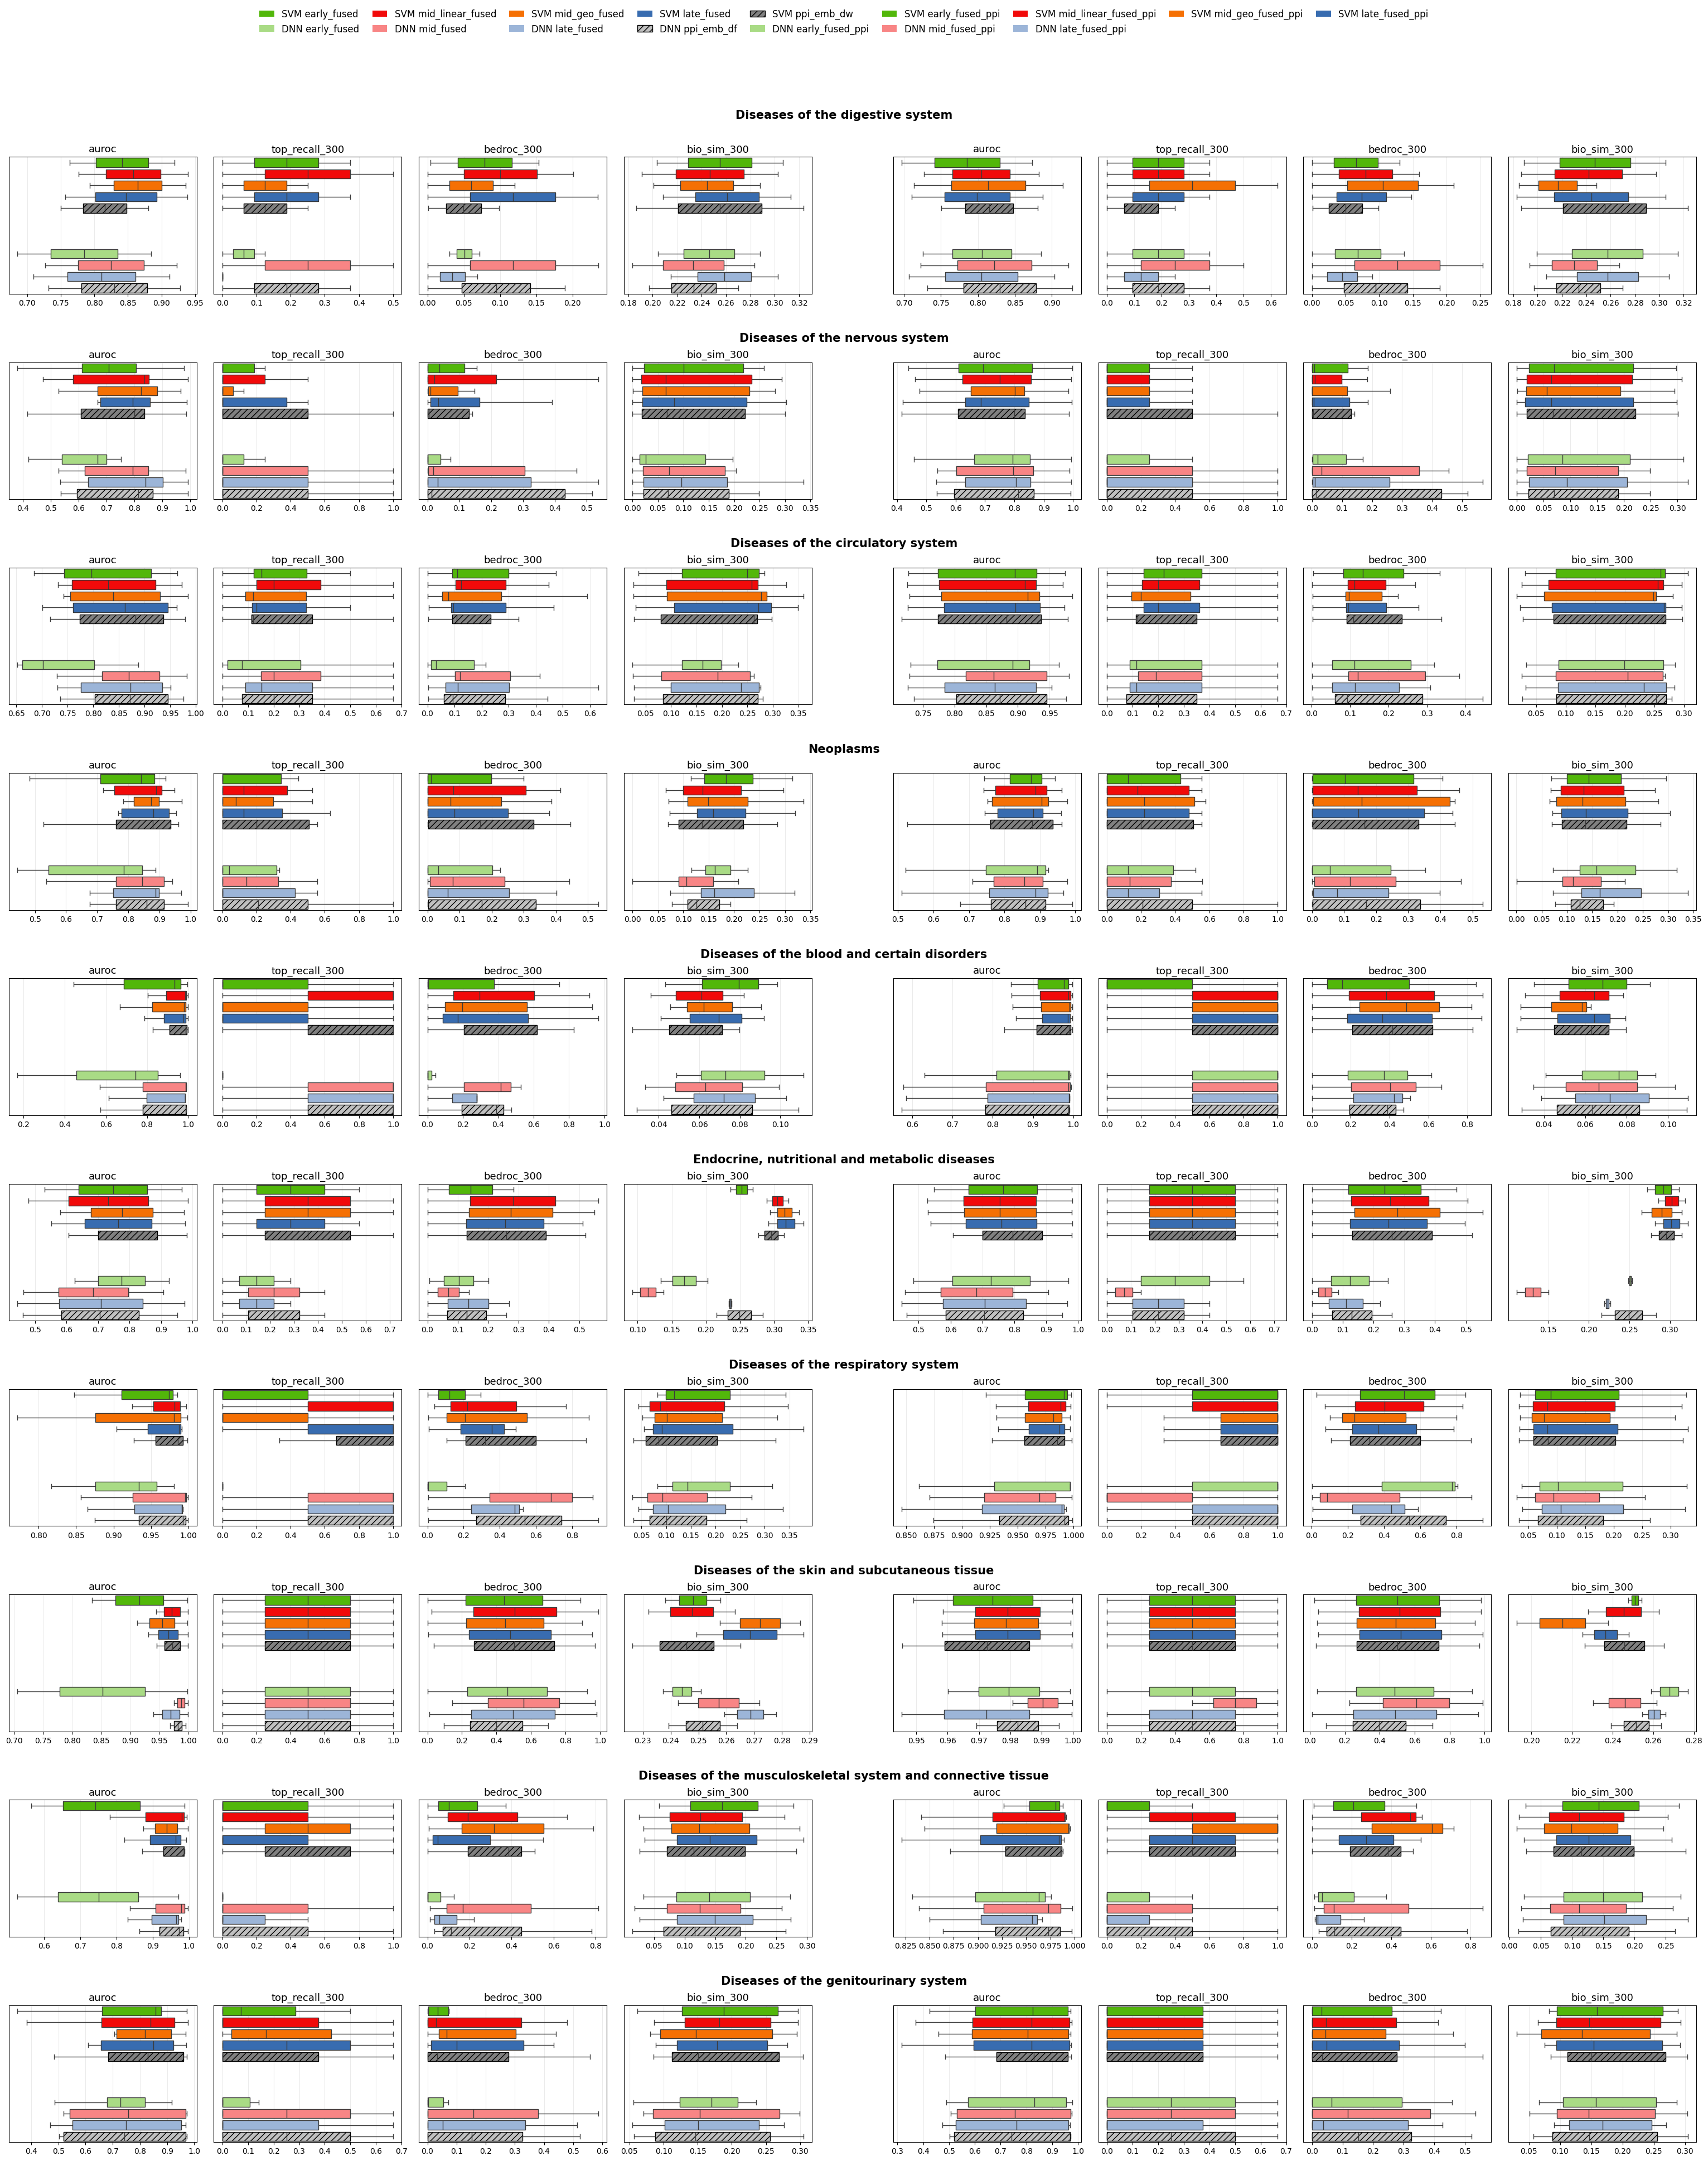

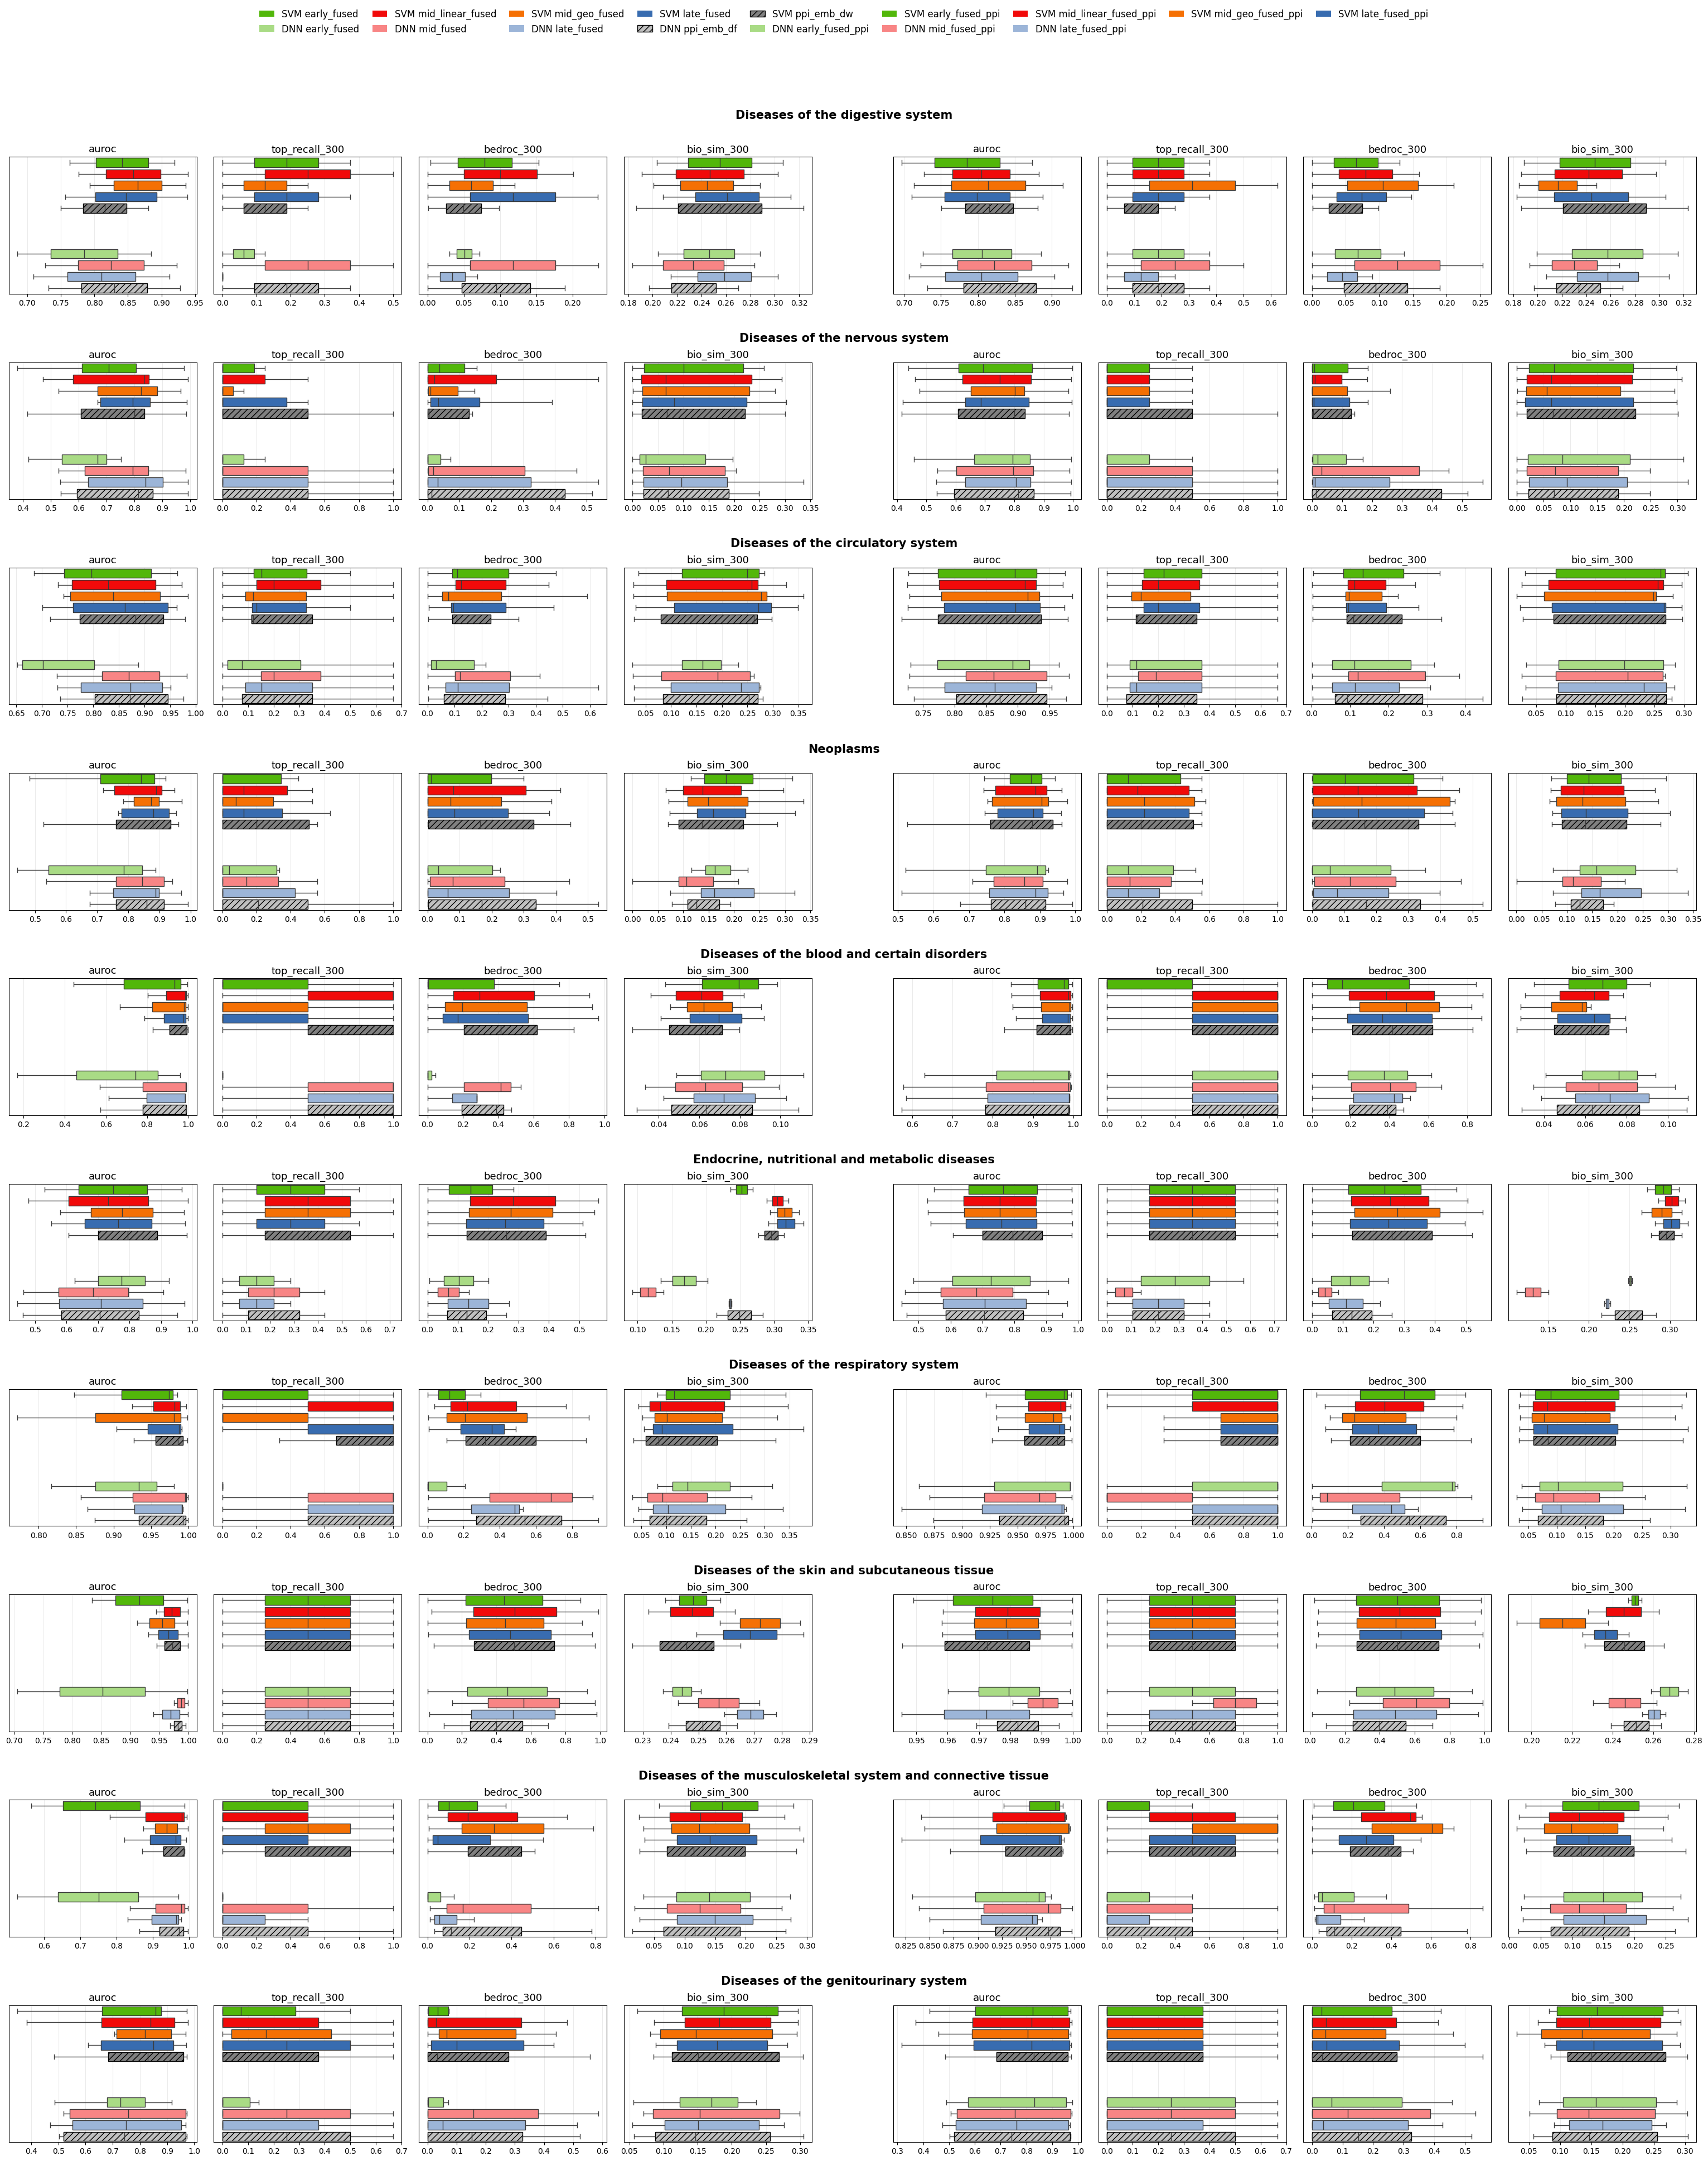

In [6]:
metrics = ['auroc','top_recall_300', 'bedroc_300','bio_sim_300']

# all_fused selections
selA1 = ['ppi_emb_dw','early_fused', 'late_fused', 'mid_fused',
         'mid_linear_fused','mid_geo_fused']
selA2 = ['ppi_emb_df','early_fused', 'early_fused_ppi', 'late_fused',
         'late_fused_ppi','mid_fused', 'mid_fused_ppi', 'mid_geo_fused_ppi',
         'mid_linear_fused', 'mid_linear_fused_ppi','mid_geo_fused']
subA1 = merged_df[(merged_df['setting']=='df_gnn_occsvm_pred') & (merged_df['method'].isin(selA1))]
subA2 = merged_df[(merged_df['setting']=='2019_nn_all_pred')   & (merged_df['method'].isin(selA2))]

# ppi_fused selections
selB1 = ['ppi_emb_dw','early_fused', 'early_fused_ppi', 'late_fused',
         'late_fused_ppi','mid_fused', 'mid_fused_ppi', 'mid_geo_fused_ppi',
         'mid_linear_fused', 'mid_linear_fused_ppi','mid_geo_fused']
selB2 = ['ppi_emb_df','early_fused', 'early_fused_ppi', 'late_fused',
         'late_fused_ppi','mid_fused', 'mid_fused_ppi', 'mid_geo_fused_ppi',
         'mid_linear_fused', 'mid_linear_fused_ppi','mid_geo_fused']
subB1 = merged_df[(merged_df['setting']=='df_gnn_occsvm_pred') & (merged_df['method'].isin(selB1))]
subB2 = merged_df[(merged_df['setting']=='2019_nn_all_pred')   & (merged_df['method'].isin(selB2))]

from visualize_plot_combined import plot_all_diseases_combined

disease_data = []
for disease in disease_list:
    a1 = subA1[subA1['category']==disease]
    a2 = subA2[subA2['category']==disease]
    b1 = subB1[subB1['category']==disease]
    b2 = subB2[subB2['category']==disease]

    disease_data.append({
        'name': disease,
        'df_long_a':  a1.melt(id_vars=['disease','method'], value_vars=metrics,
                              var_name='metric', value_name='value'),
        'svm_a':      ['early_fused', 'mid_linear_fused', 'mid_geo_fused', 'late_fused', 'ppi_emb_dw'],
        'df_long2_a': a2.melt(id_vars=['disease','method'], value_vars=metrics,
                              var_name='metric', value_name='value'),
        'dnn_a':      ['early_fused', 'mid_fused', 'late_fused', 'ppi_emb_df'],
        'df_long_b':  b1.melt(id_vars=['disease','method'], value_vars=metrics,
                              var_name='metric', value_name='value'),
        'svm_b':      ['early_fused_ppi', 'mid_linear_fused_ppi', 'mid_geo_fused_ppi','late_fused_ppi', 'ppi_emb_dw'],
        'df_long2_b': b2.melt(id_vars=['disease','method'], value_vars=metrics,
                              var_name='metric', value_name='value'),
        'dnn_b':      ['early_fused_ppi', 'mid_fused_ppi','late_fused_ppi', 'ppi_emb_df'],
    })

plot_all_diseases_combined(disease_data, metrics)